# 02 — AX-21 isotherm: data vs. published-parameter model (Gate V2, part 1)

Builds Figure **F2** (§3.10): the digitized 77 K AX-21 excess data, the modified
Dubinin–Astakhov model at the **published** parameters (excess and absolute shown
separately), and the residuals. Computes the RMSE between model excess and the
digitized points and compares it to the threshold pre-registered in
`docs/validation_plan.md` (Gate V2, part 1, §3.8).

The refit ("your fit") line is added on the next step (CC-4); F2 is completed then.

**Data provenance.** `data/validation/ax21_digitized.csv` — the 77 K excess isotherm
(× markers) digitized from Fig. 1(a) of Richard, Bénard & Chahine, *Adsorption*
**15**:43–51 (2009), DOI 10.1007/s10450-009-9149-x. All physics lives in `h2star`;
this notebook only orchestrates package calls and plots (§4.3).

In [1]:
from pathlib import Path
import io

import numpy as np

from h2star.isotherm import Material, ModifiedDA, rmse
from h2star.viz import plot_ax21_isotherm

REPO_ROOT = Path.cwd()
DIGITIZED = REPO_ROOT / "data" / "validation" / "ax21_digitized.csv"
AX21_YAML = REPO_ROOT / "data" / "materials" / "ax21.yaml"
FIG_PATH = REPO_ROOT / "figures" / "F2_ax21_isotherm.png"

lines = [
    ln for ln in DIGITIZED.read_text().splitlines()
    if ln.strip() and not ln.lstrip().startswith("#")
]
raw = np.genfromtxt(io.StringIO("\n".join(lines)), delimiter=",", names=True)

P_data_mpa = np.asarray(raw["pressure_mpa"], dtype=float)
n_exc_data = np.asarray(raw["n_excess_mol_kg"], dtype=float)

_order = np.argsort(P_data_mpa)
P_data_mpa = P_data_mpa[_order]
n_exc_data = n_exc_data[_order]

In [2]:
T = 77.0  # K — temperature of the digitized isotherm (Fig. 1a, 77 K curve)

material = Material.from_yaml(AX21_YAML)
da = ModifiedDA(material)

P_data_pa = P_data_mpa * 1e6
n_exc_model_at_data = da.n_excess(P_data_pa, T)
residuals = n_exc_model_at_data - n_exc_data
rmse_value = rmse(n_exc_model_at_data, n_exc_data)

P_curve_pa = np.logspace(np.log10(P_data_pa.min()), np.log10(P_data_pa.max()), 400)
n_exc_curve = da.n_excess(P_curve_pa, T)
n_abs_curve = da.n_absolute(P_curve_pa, T)

print(f"Gate V2 part 1 — RMSE(model excess vs digitized, 77 K) = {rmse_value:.3f} mol/kg")

Gate V2 part 1 — RMSE(model excess vs digitized, 77 K) = 1.109 mol/kg


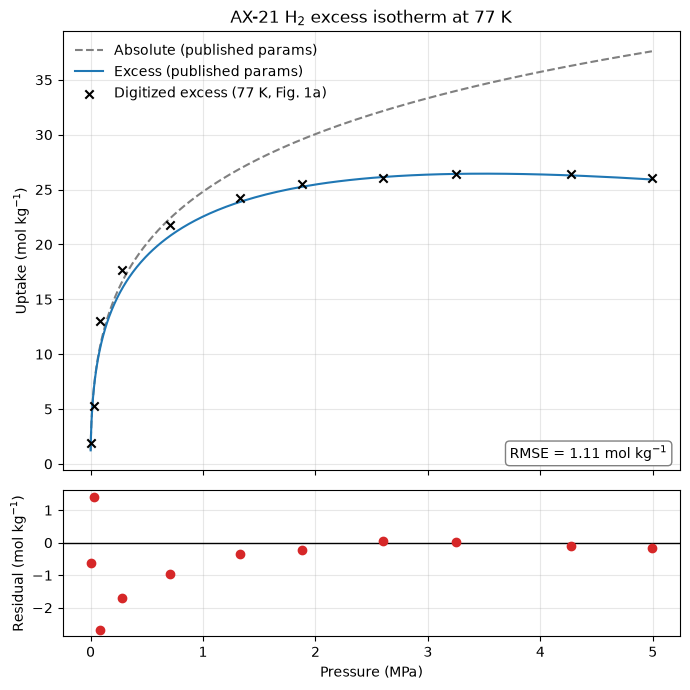

In [3]:
fig = plot_ax21_isotherm(
    P_data_mpa=P_data_mpa,
    n_excess_data=n_exc_data,
    P_curve_mpa=P_curve_pa / 1e6,
    n_excess_curve=n_exc_curve,
    n_absolute_curve=n_abs_curve,
    residuals=residuals,
    rmse_value=rmse_value,
    savepath=FIG_PATH,
)

In [4]:
from pathlib import Path
assert str(Path.cwd()).endswith("/research/h2star"), f"Wrong cwd: {Path.cwd()}"

## 5. Refit of the digitized 77 K isotherm

The digitized data is a single isotherm, so the characteristic-energy parameters enter only
through the lump E(77 K) = alpha + beta·77 and are not separately identifiable. beta is
therefore held fixed at the published 18.9 J/(mol·K); the fitted parameters are
(n_max, alpha | beta fixed, log10 p0, v_a). Recovery pass bands were pre-registered in
docs/validation_plan.md and committed before this section was first executed.

In [5]:
import io
import numpy as np
from h2star.isotherm import Material, ModifiedDA, rmse

DIGITIZED = Path.cwd() / "data" / "validation" / "ax21_digitized.csv"
lines = [ln for ln in DIGITIZED.read_text().splitlines()
         if ln.strip() and not ln.lstrip().startswith("#")]
d = np.genfromtxt(io.StringIO("\n".join(lines)), delimiter=",", names=True)
P_data_pa = d["pressure_mpa"] * 1e6
n_exc_data = d["n_excess_mol_kg"]

mat_pub = Material.from_yaml(Path.cwd() / "data" / "materials" / "ax21.yaml")
da_pub = ModifiedDA(mat_pub)
rmse_pub = rmse(da_pub.n_excess(P_data_pa, 77.0), n_exc_data)
print(f"{len(P_data_pa)} points | published-parameter RMSE = {rmse_pub:.3f} mol/kg")

11 points | published-parameter RMSE = 1.109 mol/kg


In [6]:
from h2star.fitting import fit_modified_da, fit_report

fit = fit_modified_da(P_data_pa, 77.0, n_exc_data, mat_pub)
print(fit_report(fit, mat_pub))

parameter            fitted +/- 1sigma       published      difference
----------------------------------------------------------------------
n_max                    29.86 +/- 9.3            71.6         -58.30%
alpha                 1705 +/- 7.8e+02            3080         -44.63%
beta      fixed (not identifiable at single T)            18.9              --
p0             1e+07 Pa (+/- 0.84 dex)        1.47e+09      -2.167 dex
v_a              0.0003835 +/- 0.00082         0.00143         -73.18%
----------------------------------------------------------------------
rmse             = 0.802 mol/kg
n_points         = 11
dof              = 7
condition number = 1.052e+14  (J^T J)


In [7]:
rec = dict(zip(fit.param_names, fit.popt))
bands = {
    "n_max":    (53.7, 89.5, rec["n_max"]),
    "alpha":    (2156.0, 4004.0, rec["alpha"]),
    "log10_p0": (8.467, 9.867, rec["log10_p0"]),
    "v_a":      (9.30e-4, 1.93e-3, rec["v_a"]),
}
for k, (lo, hi, v) in bands.items():
    print(f"{k:9s} {v:12.5g}   band [{lo:.5g}, {hi:.5g}]  -> {'IN' if lo <= v <= hi else 'OUT'}")
print(f"RMSE      refit {fit.rmse:.3f} vs published {rmse_pub:.3f}"
      f"  -> {'IN' if fit.rmse <= rmse_pub + 1e-9 else 'OUT'}")
print("\nParameter correlation matrix (n_max, alpha, log10_p0, v_a):")
print(np.round(fit.correlation, 3))

n_max           29.857   band [53.7, 89.5]  -> OUT
alpha           1705.3   band [2156, 4004]  -> OUT
log10_p0             7   band [8.467, 9.867]  -> OUT
v_a         0.00038348   band [0.00093, 0.00193]  -> OUT
RMSE      refit 0.802 vs published 1.109  -> IN

Parameter correlation matrix (n_max, alpha, log10_p0, v_a):
[[1.    0.952 0.989 0.989]
 [0.952 1.    0.985 0.913]
 [0.989 0.985 1.    0.961]
 [0.989 0.913 0.961 1.   ]]


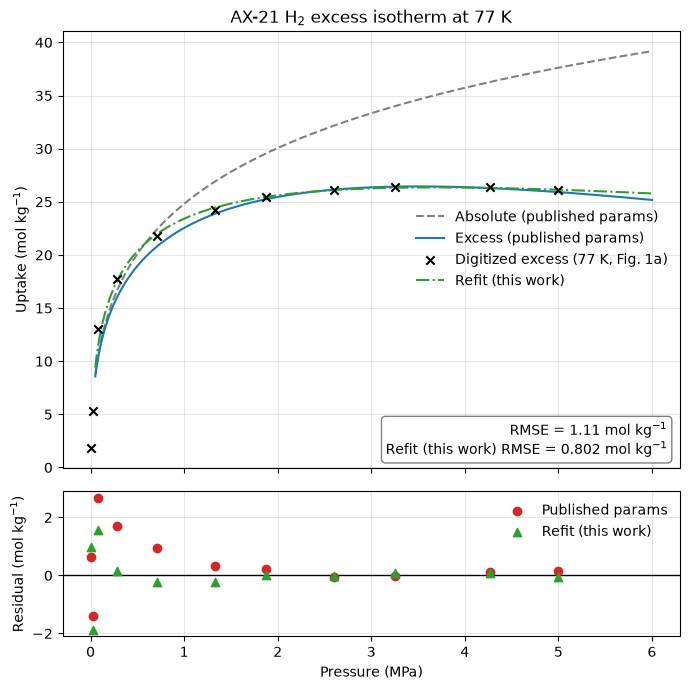

In [8]:
from h2star.viz import plot_ax21_isotherm

P_grid_pa = np.linspace(0.05e6, 6.0e6, 400)
da_fit = ModifiedDA(fit.material)

fig = plot_ax21_isotherm(
    P_data_mpa=P_data_pa / 1e6,
    n_excess_data=n_exc_data,
    P_curve_mpa=P_grid_pa / 1e6,
    n_excess_curve=da_pub.n_excess(P_grid_pa, 77.0),
    n_absolute_curve=da_pub.n_absolute(P_grid_pa, 77.0),
    residuals=n_exc_data - da_pub.n_excess(P_data_pa, 77.0),
    rmse_value=rmse_pub,
    n_excess_fit=da_fit.n_excess(P_grid_pa, 77.0),
    residuals_fit=n_exc_data - da_fit.n_excess(P_data_pa, 77.0),
    rmse_fit=fit.rmse,
    savepath=Path.cwd() / "figures" / "F2_ax21_isotherm.png",
)

**Recovered vs. published.** The refit does not recover the published parameters: the
optimizer descends the single-isotherm identifiability ridge (correlations 0.91–0.99,
cond(JᵀJ) ≈ 1e14) to a corner solution at the p0 lower bound, trading a physically
implausible parameter vector for ~0.3 mol/kg of RMSE at the low-pressure knee. The
pre-registered Gate V2 recovery verdict is FAIL, recorded with interpretation in
docs/validation_plan.md. The fixed-p0 diagnostic in Section 5.1 supports this: pinning
p0 alone returns n_max, alpha, and v_a to within ~6% of published. The comparison table
above becomes part of T4.

### 5.1 Post-hoc identifiability diagnostic (not a gate)

The pre-registered recovery gate FAILED: the optimizer descended the single-isotherm
identifiability ridge to a corner solution pinned at the p0 lower bound (verdict in
docs/validation_plan.md). As a diagnostic — run after that outcome was known, with no
pass band applied — the refit is repeated with p0 additionally fixed at the published
1.47e9 Pa, to test whether the remaining parameters (n_max, alpha, v_a) are recoverable
once the flattest ridge direction is pinned.

In [9]:
fit_diag = fit_modified_da(P_data_pa, 77.0, n_exc_data, mat_pub, fix_p0=True)
print(fit_report(fit_diag, mat_pub))
print("\nCorrelation matrix (n_max, alpha, v_a):")
print(np.round(fit_diag.correlation, 3))

parameter            fitted +/- 1sigma       published      difference
----------------------------------------------------------------------
n_max                    67.82 +/- 7.8            71.6          -5.27%
alpha                   3266 +/- 2e+02            3080          +6.04%
beta      fixed (not identifiable at single T)            18.9              --
p0        fixed (post-hoc identifiability diagnostic)        1.47e+09              --
v_a               0.001423 +/- 0.00037         0.00143          -0.50%
----------------------------------------------------------------------
rmse             = 0.9073 mol/kg
n_points         = 11
dof              = 8
condition number = 6.548e+12  (J^T J)

Correlation matrix (n_max, alpha, v_a):
[[ 1.    -0.965  0.942]
 [-0.965  1.    -0.842]
 [ 0.942 -0.842  1.   ]]
